# Simulación del Hamiltoniano de Ising

Vamos a utilizar las herramientas de la computación cuántica para poder realizar simulaciones del Hamiltoniano de Ising con campo transverso:



In [10]:
from funciones_ising_hackathon import *
import numpy as np
import matplotlib.pyplot as plt

Vamos a implementar el Hamiltoniano Trotterizado y compararlo con el Hamiltoniano analítico obtenido por Diagonalización:

In [11]:
J = 1.0
h = 0.5
n_q = 4
r = 10
t = 1.0

psi_trotter = H_trott1_c(  # Hamiltoniano Trotterizado
    J=J,
    h=h,
    n_q=n_q,
    r=r,
    t=t
)

print(psi_trotter)

Statevector([-0.38110897-0.82031334j, -0.096383  -0.13714844j,
             -0.09641597-0.13698581j,  0.00290174-0.11657033j,
             -0.09886633-0.14120471j, -0.0187001 -0.0100051j ,
              0.00402522-0.11857106j,  0.04788949-0.03163649j,
             -0.12035125-0.11058514j, -0.02136804-0.11313144j,
             -0.02108316-0.00230131j,  0.03910316-0.04207165j,
              0.00187532-0.11555905j,  0.04697226-0.03727477j,
              0.04524244-0.02874128j,  0.00340511+0.03156357j],
            dims=(2, 2, 2, 2))


In [12]:
psi_exacta = evolve_tfim_exact(  #Hamiltoniano exacto
    t=t,
    h=h,
    J=J,
    r=r,
    n_qubits=n_q,
    periodic=True
)

Para poder comparar ambos valores necesitamos encontrar una métrica que nos relaciones como podemos conectar ambos valores. La métrica que tiene mas sentido es la Fidelidad de estados cuánticos, que nos indica que tanto se parece un estado cuántico a otro. El valor matemático de la fidelidad es:

$$F=|\langle \psi_{exacta}|\psi_{trotterizada}\rangle|^2$$

Veamos para los parámetros dados antes, como se visualiza la Fidelidad

In [13]:
fidelidad = abs(
    psi_exacta.inner(psi_trotter)
)**2

print(f"Fidelidad: {fidelidad:.8f}")

Fidelidad: 0.99501046


Ahora, para verificar la convergencia del valor r, vamos a iterarlo por número de pasos y graficarlo:

In [14]:
J = 1.0
h = 1.0
n_q = 6
t = 1.0

valores_r = [1, 2,3,4, 5,8, 10, 20, 50]

psi_exacta = evolve_tfim_exact(
    t=t,
    h=h,
    J=J,
    n_qubits=n_q,
    r=1,
    periodic=True
)

for r in valores_r:
    psi_trotter = H_trott1_c(
        J=J,
        h=h,
        n_q=n_q,
        r=r,
        t=t
    )

    fidelidad = abs(
        psi_exacta.inner(psi_trotter)
    )**2

    print(
        f"r = {r:2d} | "
        f"dt = {t/r:.4f} | "
        f"F = {fidelidad:.8f}"
    )

r =  1 | dt = 1.0000 | F = 0.07157111
r =  2 | dt = 0.5000 | F = 0.59106062
r =  3 | dt = 0.3333 | F = 0.81236192
r =  4 | dt = 0.2500 | F = 0.89413920
r =  5 | dt = 0.2000 | F = 0.93236443
r =  8 | dt = 0.1250 | F = 0.97376072
r = 10 | dt = 0.1000 | F = 0.98326271
r = 20 | dt = 0.0500 | F = 0.99584928
r = 50 | dt = 0.0200 | F = 0.99933963


Podemos graficar la evolución de la convergencia facilmente:

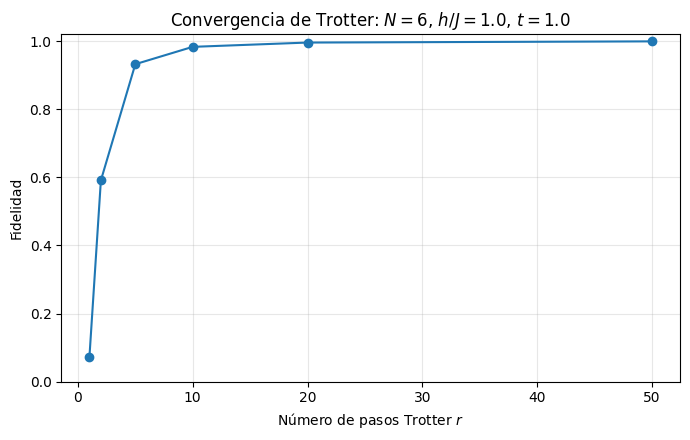

In [15]:
J = 1.0
h = 1.0
n_q = 6
t = 1.0

valores_r = np.array([1, 2, 5, 10, 20, 50])
fidelidades = []

psi_exacta = evolve_tfim_exact(
    t=t,
    h=h,
    J=J,
    n_qubits=n_q,
    r=1,
    periodic=True
)

for r in valores_r:
    psi_trotter = H_trott1_c(
        J=J,
        h=h,
        n_q=n_q,
        r=int(r),
        t=t
    )

    F = abs(
        psi_exacta.inner(psi_trotter)
    )**2

    fidelidades.append(F)

plt.figure(figsize=(7, 4.5))

plt.plot(
    valores_r,
    fidelidades,
    marker="o"
)

plt.xlabel("Número de pasos Trotter $r$")
plt.ylabel("Fidelidad")
plt.title(
    rf"Convergencia de Trotter: "
    rf"$N={n_q}$, $h/J={h/J}$, $t={t}$"
)

plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Veamos la degradación del modelo con el aumento del tamaño de la cadena de espines y si esto acaba afectando el sistema

In [16]:
J = 1.0
h = 1.0
t = 1.0
r = 10

tamanos = [4, 6, 8, 10, 12] #Expandir esto utilizando simuladores para evitar que se demore demasiado el cálculo de la fidelidad
fidelidades = []

for n_q in tamanos:
    psi_exacta = evolve_tfim_exact(
        t=t,
        h=h,
        J=J,
        n_qubits=n_q,
        r=1,
        periodic=True
    )

    psi_trotter = H_trott1_c(
        J=J,
        h=h,
        n_q=n_q,
        r=r,
        t=t
    )

    F = abs(
        psi_exacta.inner(psi_trotter)
    )**2

    fidelidades.append(F)

    print(
        f"N = {n_q:2d} | "
        f"F = {F:.8f}"
    )

N =  4 | F = 0.98554828
N =  6 | F = 0.98326271
N =  8 | F = 0.97937046
N = 10 | F = 0.97544195
N = 12 | F = 0.97153081


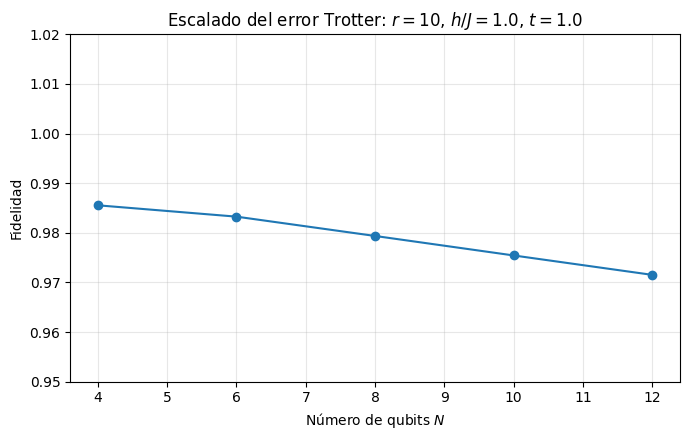

In [17]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    tamanos,
    fidelidades,
    marker="o"
)

plt.xlabel("Número de qubits $N$")
plt.ylabel("Fidelidad")
plt.title(
    rf"Escalado del error Trotter: "
    rf"$r={r}$, $h/J={h/J}$, $t={t}$"
)

plt.ylim(0.95, 1.02)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

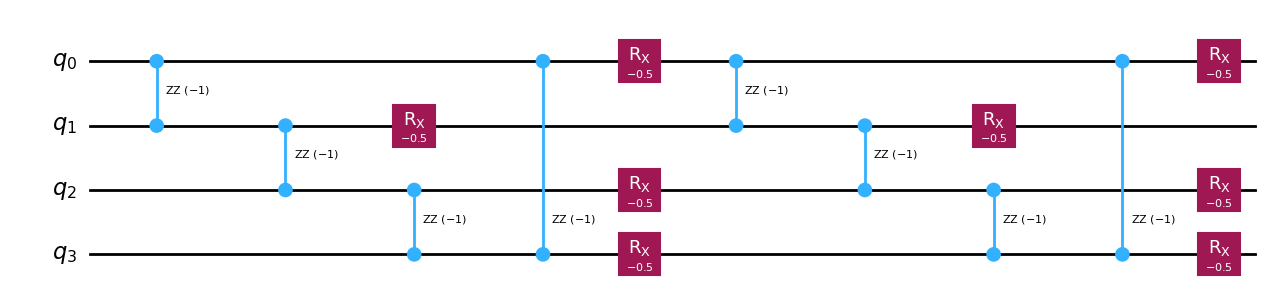

In [18]:
qc = circuito_tfim_trotter_cerrado(
    J=1.0,
    h=0.5,
    n_q=4,
    r=2,
    t=1.0
)

qc.draw("mpl")

In [19]:
print("Profundidad:", qc.depth())
print("Número total de operaciones:", qc.size())
print("Conteo de compuertas:", qc.count_ops())

Profundidad: 10
Número total de operaciones: 16
Conteo de compuertas: OrderedDict([('rzz', 8), ('rx', 8)])


Una vez ya tengamos esto, veamos como evoluciona la dinámica de los observables cuánticos despues de esto.

In [20]:
J = 1.0
h = 0.5
n_q = 6
r = 20
t = 1.0

psi_t = evolucion_tfim_trotter_cerrada(
    J=J,
    h=h,
    n_q=n_q,
    r=r,
    t=t
)

In [21]:
Mz = magnetizacion_z(n_q)

Czz = correlacion_zz_vecinos_cerrada(n_q)

In [22]:
mz = psi_t.expectation_value(Mz)
czz = psi_t.expectation_value(Czz)

mz = float(np.real_if_close(mz))
czz = float(np.real_if_close(czz))

print(f"<Mz>  = {mz:.8f}")
print(f"<Czz> = {czz:.8f}")

<Mz>  = 0.86772074
<Czz> = 0.81989909


Revisemos el caso $t=0$

In [23]:
psi_0 = evolucion_tfim_trotter_cerrada(
    J=1.0,
    h=0.5,
    n_q=6,
    r=1,
    t=0.0
)

print(
    float(np.real_if_close(
        psi_0.expectation_value(magnetizacion_z(6))
    ))
)

print(
    float(np.real_if_close(
        psi_0.expectation_value(
            correlacion_zz_vecinos_cerrada(6)
        )
    ))
)

0.9999999999999999
0.9999999999999999


Ahora veamos como evoluciona el estado:

In [24]:
datos = barrido_temporal_tfim_trotter_cerrado(
    J=1.0,
    h=2.0,
    n_q=6,
    r=1000,
    t_min=0.0,
    t_max=20.0,
    puntos=101
)

In [25]:
print(datos["tiempos"][:5])
print(datos["mz"][:5])
print(datos["czz"][:5])

[0.  0.2 0.4 0.6 0.8]
[ 1.          0.71113865  0.11532807 -0.37057648 -0.53192386]
[1.         0.51101717 0.14661556 0.47295114 0.57480559]


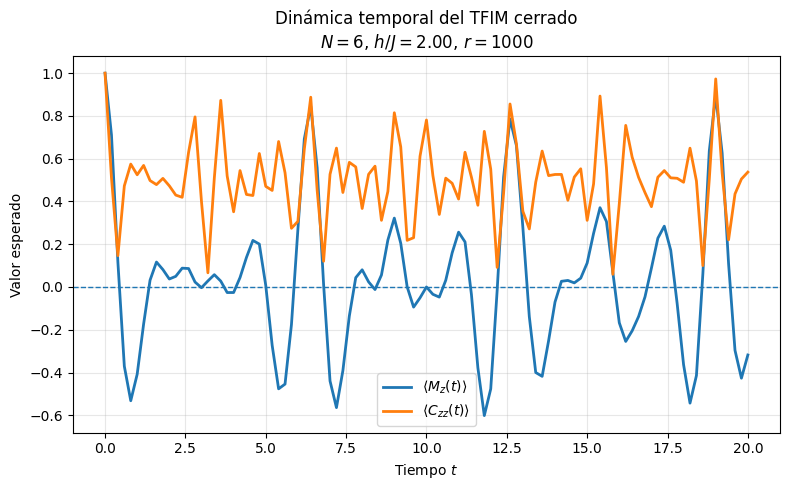

In [26]:
tiempos = datos["tiempos"]
mz = datos["mz"]
czz = datos["czz"]

plt.figure(figsize=(8, 5))

plt.plot(
    tiempos,
    mz,
    linewidth=2,
    label=r"$\langle M_z(t)\rangle$"
)

plt.plot(
    tiempos,
    czz,
    linewidth=2,
    label=r"$\langle C_{zz}(t)\rangle$"
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(r"Tiempo $t$")
plt.ylabel("Valor esperado")

plt.title(
    rf"Dinámica temporal del TFIM cerrado"
    "\n"
    rf"$N={datos['n_q']}$, "
    rf"$h/J={datos['h']/datos['J']:.2f}$, "
    rf"$r={datos['r']}$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
regimenes = {
    "Ferromagnético": 0.5,
    "Cercano al crítico": 1.0,
    "Paramagnético": 2.0
}

resultados = {}

for nombre, h in regimenes.items():

    resultados[nombre] = (
        barrido_temporal_tfim_trotter_cerrado(
            J=1.0,
            h=h,
            n_q=6,
            r=40,
            t_min=0.0,
            t_max=15.0,
            puntos=101
        )
    )

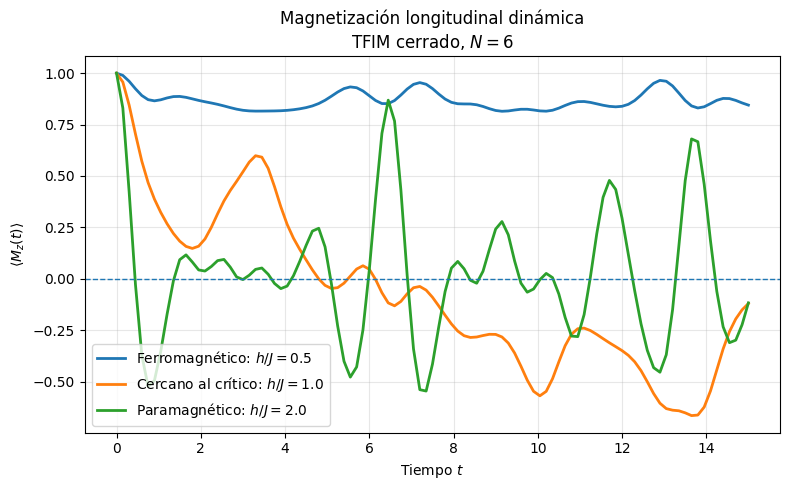

In [28]:
plt.figure(figsize=(8, 5))

for nombre, datos in resultados.items():

    plt.plot(
        datos["tiempos"],
        datos["mz"],
        linewidth=2,
        label=(
            rf"{nombre}: "
            rf"$h/J={datos['h']/datos['J']:.1f}$"
        )
    )

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xlabel(r"Tiempo $t$")
plt.ylabel(r"$\langle M_z(t)\rangle$")
plt.title(
    r"Magnetización longitudinal dinámica"
    "\n"
    r"TFIM cerrado, $N=6$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

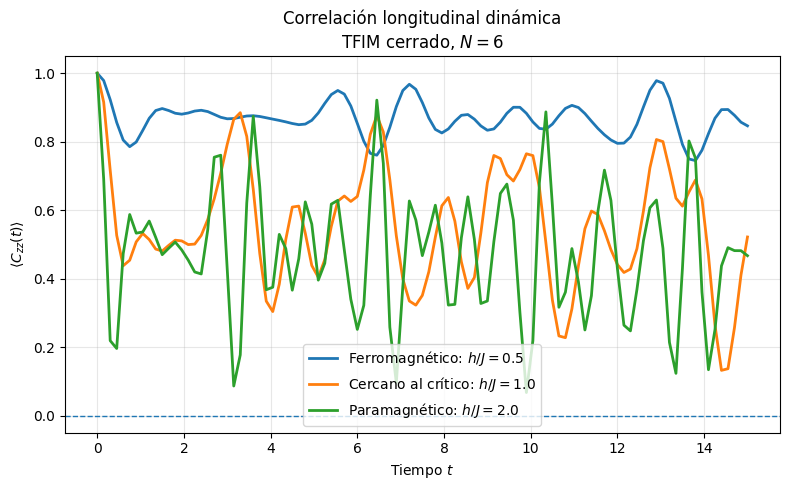

In [29]:
plt.figure(figsize=(8, 5))

for nombre, datos in resultados.items():

    plt.plot(
        datos["tiempos"],
        datos["czz"],
        linewidth=2,
        label=(
            rf"{nombre}: "
            rf"$h/J={datos['h']/datos['J']:.1f}$"
        )
    )

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xlabel(r"Tiempo $t$")
plt.ylabel(r"$\langle C_{zz}(t)\rangle$")
plt.title(
    r"Correlación longitudinal dinámica"
    "\n"
    r"TFIM cerrado, $N=6$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## VQE???

Haremos un intento de programar el VQE. Usaremos Pennylane inicialmente, pero despues convertiremos esto a Guppy

In [1]:
# Las funciones VQE se importan desde funciones_ising_hackathon.py.
import pennylane as qml

In [4]:
resultado = vqe_ising(
    n_qubits=4,
    J=1.0,
    h=0.5,
    n_layers=1,          # RX-RY-RZ -> CNOTs -> RX-RY-RZ
    learning_rate=0.05,
    max_steps=500,
    tol=1e-8,
    patience=15,
    seed=42,
    mostrar_cada=25,
)

Energía inicial: -4.064510672355
Paso    1 | E = -4.147120582911 | ΔE = 8.261e-02
Paso   25 | E = -4.245981279172 | ΔE = 1.516e-03
Paso   50 | E = -4.250718536100 | ΔE = 1.306e-04
Paso   75 | E = -4.250941727253 | ΔE = 8.186e-07
Paso  100 | E = -4.250978374498 | ΔE = 9.804e-08
Paso  125 | E = -4.250980117745 | ΔE = 3.416e-08
Paso  150 | E = -4.250980374091 | ΔE = 7.960e-09

Convergencia alcanzada en el paso 158.

Resultado final
------------------------------
Energía VQE:    -4.250980382021
Energía exacta: -4.271558410140
Error absoluto: 2.058e-02


In [5]:
resultado_ferro = vqe_ising(
    n_qubits=4,
    J=1.0,
    h=0.5,
    n_layers=2,
)

resultado_critico = vqe_ising(
    n_qubits=4,
    J=1.0,
    h=1.0,
    n_layers=2,
)

resultado_paramagnetico = vqe_ising(
    n_qubits=4,
    J=1.0,
    h=2.0,
    n_layers=2,
)

Energía inicial: -3.896674380837
Paso    1 | E = -4.042450461634 | ΔE = 1.458e-01
Paso   25 | E = -4.242819589956 | ΔE = 1.058e-03
Paso   50 | E = -4.251196056292 | ΔE = 3.270e-05
Paso   75 | E = -4.251937038928 | ΔE = 1.108e-05
Paso  100 | E = -4.252883123044 | ΔE = 6.674e-05
Paso  125 | E = -4.254229271770 | ΔE = 8.106e-07
Paso  150 | E = -4.254640446610 | ΔE = 4.450e-05
Paso  175 | E = -4.261262784820 | ΔE = 4.855e-04
Paso  200 | E = -4.269614234768 | ΔE = 2.924e-04
Paso  225 | E = -4.270772908260 | ΔE = 3.562e-05
Paso  250 | E = -4.270931427007 | ΔE = 3.213e-05
Paso  275 | E = -4.271059473796 | ΔE = 4.471e-06
Paso  300 | E = -4.271151040354 | ΔE = 7.770e-05
Paso  325 | E = -4.271206028170 | ΔE = 2.794e-05
Paso  350 | E = -4.270329704639 | ΔE = 6.368e-05
Paso  375 | E = -4.271299307830 | ΔE = 1.229e-05
Paso  400 | E = -4.271288479288 | ΔE = 4.156e-05
Paso  425 | E = -4.271252090236 | ΔE = 4.444e-05
Paso  450 | E = -4.271347974934 | ΔE = 4.285e-05
Paso  475 | E = -4.271292981593 | ΔE

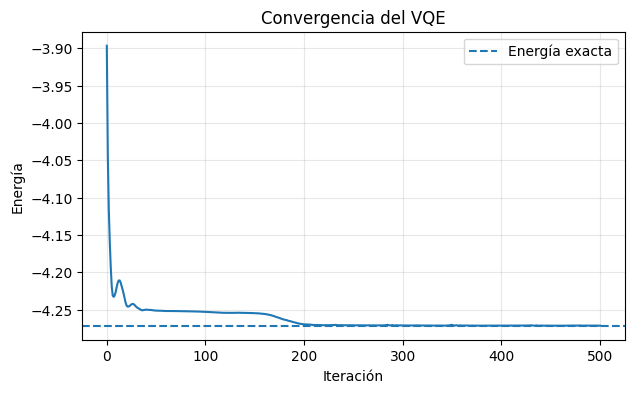

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(resultado_ferro["historial"])

if "energia_exacta" in resultado_ferro:
    plt.axhline(
        resultado_ferro["energia_exacta"],
        linestyle="--",
        label="Energía exacta",
    )

plt.xlabel("Iteración")
plt.ylabel("Energía")
plt.title("Convergencia del VQE")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [7]:
parametros = resultado["parametros_optimos"]

print(
    qml.draw(
        resultado["circuito_energia"],
        decimals=2,
    )(parametros)
)

0: ──RX(0.00)───RY(0.00)──RZ(0.10)──╭●───────╭X──RX(-0.00)──RY(0.26)──RZ(-0.02)─┤ ╭<𝓗>
1: ──RX(-0.00)──RY(0.01)──RZ(-0.05)─╰X─╭●────│───RX(-0.00)──RY(0.25)──RZ(-0.01)─┤ ├<𝓗>
2: ──RX(-0.00)──RY(0.01)──RZ(-0.50)────╰X─╭●─│───RX(0.01)───RY(0.25)──RZ(0.06)──┤ ├<𝓗>
3: ──RX(0.00)───RY(0.03)──RZ(-0.00)───────╰X─╰●──RX(0.01)───RY(0.26)──RZ(0.04)──┤ ╰<𝓗>


In [8]:
resultado["parametros_optimos"].shape

(2, 4, 3)

In [13]:
tabla, estados = comparar_vqe_tfim(
    n_qubits=4,
    J=1.0,
    valores_h=(0.5, 1.0, 2.0),
    n_layers=3,
    learning_rate=0.03,
    max_steps=800,
    seeds=(3, 7, 11, 19, 42),
)

display(
    tabla.round(6)
)


J = 1.0, h = 0.5, h/J = 0.5
Energía inicial: -4.003523584537
Paso    1 | E = -4.121475586755 | ΔE = 1.180e-01
Energía inicial: -3.846251973128
Paso    1 | E = -3.977405698817 | ΔE = 1.312e-01
Energía inicial: -3.831703720470
Paso    1 | E = -3.966362268625 | ΔE = 1.347e-01
Energía inicial: -3.959747860496
Paso    1 | E = -4.060605858492 | ΔE = 1.009e-01
Energía inicial: -3.869342478712
Paso    1 | E = -4.005152834086 | ΔE = 1.358e-01

J = 1.0, h = 1.0, h/J = 1.0
Energía inicial: -4.105297682406
Paso    1 | E = -4.304184660055 | ΔE = 1.989e-01
Energía inicial: -3.800942786395
Paso    1 | E = -4.014464371256 | ΔE = 2.135e-01
Energía inicial: -3.744365335922
Paso    1 | E = -3.968251410344 | ΔE = 2.239e-01
Energía inicial: -4.014391554522
Paso    1 | E = -4.184737456174 | ΔE = 1.703e-01
Energía inicial: -3.824932430992
Paso    1 | E = -4.041496752596 | ΔE = 2.166e-01

J = 1.0, h = 2.0, h/J = 2.0
Energía inicial: -4.308845878142
Paso    1 | E = -4.692673715237 | ΔE = 3.838e-01

Convergenc

,h,h/J,E_VQE,E_exacta,error_E,fidelidad,Mz_VQE,Mz_exacto,Mz2_VQE,Mz2_exacto,Mx_VQE,Mx_exacto,Czz_VQE,Czz_exacto
0,0.5,0.5,-4.271512,-4.271558,0.000047,0.999986,0.004388,0.0,0.940766,0.940467,0.290094,0.290886,0.922831,0.922447
1,1.0,1.0,-5.226229,-5.226252,0.000023,0.999994,0.000068,-0.0,0.727079,0.727529,0.653820,0.653281,0.652737,0.653281
2,2.0,2.0,-8.543117,-8.543117,0.000000,1.000000,-0.000006,-0.0,0.442785,0.442784,0.922446,0.922447,0.290886,0.290886


In [14]:
estado_h05 = estados[0.5]["estado_vqe"]
estado_h1 = estados[1.0]["estado_vqe"]
estado_h2 = estados[2.0]["estado_vqe"]

In [ ]:
graficar_observables_vqe(tabla)

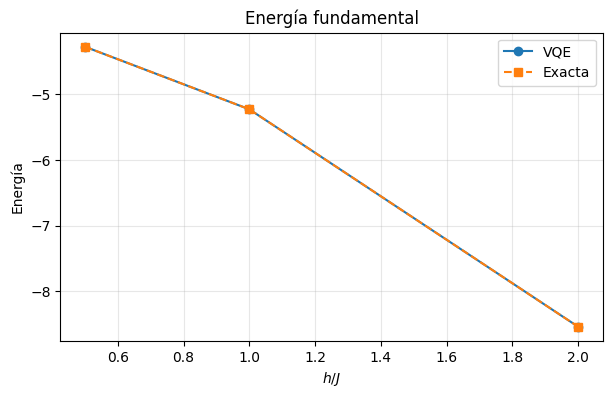

In [16]:
plt.figure(figsize=(7, 4))

plt.plot(
    tabla["h/J"],
    tabla["E_VQE"],
    marker="o",
    label="VQE",
)

plt.plot(
    tabla["h/J"],
    tabla["E_exacta"],
    marker="s",
    linestyle="--",
    label="Exacta",
)

plt.xlabel(r"$h/J$")
plt.ylabel("Energía")
plt.title("Energía fundamental")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURACIÓN
# ============================================================

n_qubits = 4
J = 1.0

valores_h = np.arange(0.2, 2.01, 0.2)

# Dos VQE independientes por cada valor de h
seeds = (3, 42)

n_layers = 3
learning_rate = 0.03
max_steps = 800


# ============================================================
# BARRIDO EN h
# ============================================================

resultados = []

for h in valores_h:

    # Evita errores numéricos como 0.6000000000000001
    h = float(np.round(h, 1))

    print("\n" + "=" * 60)
    print(f"J = {J}, h = {h}, h/J = {h / J}")
    print("=" * 60)

    # Esta función ejecuta exactamente dos VQE porque recibe dos seeds
    resultado_vqe = mejor_vqe_ising(
        n_qubits=n_qubits,
        J=J,
        h=h,
        n_layers=n_layers,
        learning_rate=learning_rate,
        max_steps=max_steps,
        seeds=seeds,
    )

    # Estado y energía obtenidos con VQE
    estado_vqe = np.asarray(
        resultado_vqe["estado_vqe"],
        dtype=complex,
    )

    energia_vqe = float(
        resultado_vqe["energia_vqe"]
    )

    H = resultado_vqe["hamiltoniano"]

    # Observables del estado encontrado por VQE
    observables_vqe = medir_observables_tfim(
        estado_vqe,
        n_qubits,
    )

    # Estado base exacto para comparar
    energia_exacta, estado_exacto = estado_base_exacto(
        H,
        n_qubits,
    )

    observables_exactos = medir_observables_tfim(
        estado_exacto,
        n_qubits,
    )

    fidelidad = float(
        np.abs(
            np.vdot(
                estado_exacto,
                estado_vqe,
            )
        ) ** 2
    )

    resultados.append({
        "h": h,
        "h/J": h / J,

        "E_VQE": energia_vqe,
        "E_exacta": energia_exacta,
        "error_E": abs(energia_vqe - energia_exacta),
        "fidelidad": fidelidad,

        "Mz_VQE": observables_vqe["Mz"],
        "Mz_exacto": observables_exactos["Mz"],

        "Mz2_VQE": observables_vqe["Mz2"],
        "Mz2_exacto": observables_exactos["Mz2"],

        "Czz_VQE": observables_vqe["Czz"],
        "Czz_exacto": observables_exactos["Czz"],

        "Mx_VQE": observables_vqe["Mx"],
        "Mx_exacto": observables_exactos["Mx"],
    })


tabla = pd.DataFrame(resultados)

display(tabla.round(6))


J = 1.0, h = 0.2, h/J = 0.2
Energía inicial: -3.942459125816
Paso    1 | E = -4.012745943429 | ΔE = 7.029e-02
Energía inicial: -3.895988507344
Paso    1 | E = -3.985447562816 | ΔE = 8.946e-02

J = 1.0, h = 0.4, h/J = 0.4
Energía inicial: -3.983168764964
Paso    1 | E = -4.085232178982 | ΔE = 1.021e-01
Energía inicial: -3.878224488256
Paso    1 | E = -3.998215829858 | ΔE = 1.200e-01

J = 1.0, h = 0.6, h/J = 0.6
Energía inicial: -4.023878404111
Paso    1 | E = -4.155760472084 | ΔE = 1.319e-01
Energía inicial: -3.860460469168
Paso    1 | E = -4.012089845580 | ΔE = 1.516e-01

J = 1.0, h = 0.8, h/J = 0.8
Energía inicial: -4.064588043258
Paso    1 | E = -4.229747335769 | ΔE = 1.652e-01
Energía inicial: -3.842696450080
Paso    1 | E = -4.025964659877 | ΔE = 1.833e-01

J = 1.0, h = 1.0, h/J = 1.0
Energía inicial: -4.105297682406
Paso    1 | E = -4.304184660055 | ΔE = 1.989e-01
Energía inicial: -3.824932430992
Paso    1 | E = -4.041496752596 | ΔE = 2.166e-01

J = 1.0, h = 1.2, h/J = 1.2
Energí

,h,h/J,E_VQE,E_exacta,error_E,fidelidad,Mz_VQE,Mz_exacto,Mz2_VQE,Mz2_exacto,Czz_VQE,Czz_exacto,Mx_VQE,Mx_exacto
0,0.2,0.2,-4.040572,-4.040594,0.000021,0.983363,0.254475,0.0,0.992167,0.992131,0.989608,0.989558,0.102675,0.102952
1,0.4,0.4,-4.169109,-4.169143,0.000033,0.998794,0.067797,-0.0,0.964634,0.964473,0.953621,0.953405,0.221641,0.222202
2,0.6,0.6,-4.402546,-4.402569,0.000023,0.999995,0.001018,-0.0,0.908647,0.908600,0.881795,0.881707,0.364736,0.364892
3,0.8,0.8,-4.755640,-4.755852,0.000212,0.999956,0.001491,0.0,0.823723,0.824104,0.774373,0.774739,0.518171,0.517780
4,1.0,1.0,-5.226034,-5.226252,0.000218,0.999959,0.000297,-0.0,0.727257,0.727529,0.652867,0.653281,0.653642,0.653281
5,1.2,1.2,-5.791824,-5.791835,0.000011,0.999998,-0.000116,-0.0,0.639271,0.639253,0.542254,0.542279,0.754752,0.754733
6,1.4,1.4,-6.425172,-6.425178,0.000006,0.999998,0.000009,0.0,0.568463,0.568411,0.452744,0.452741,0.823963,0.823967
7,1.6,1.6,-7.104011,-7.104017,0.000005,0.999999,-0.000003,0.0,0.514321,0.514489,0.383756,0.383966,0.870154,0.870024
8,1.8,1.8,-7.813225,-7.813225,0.000000,1.000000,-0.000009,0.0,0.473810,0.473810,0.331468,0.331467,0.901021,0.901022
9,2.0,2.0,-8.543117,-8.543117,0.000000,1.000000,-0.000006,-0.0,0.442785,0.442784,0.290886,0.290886,0.922446,0.922447


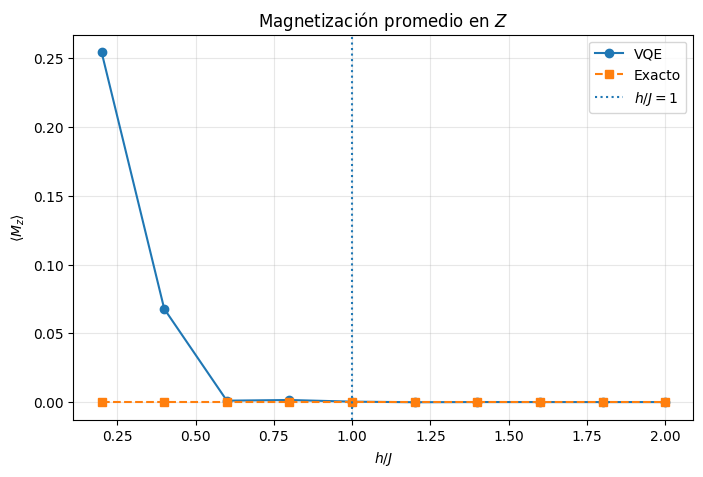

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabla["h/J"],
    tabla["Mz_VQE"],
    marker="o",
    label="VQE",
)

plt.plot(
    tabla["h/J"],
    tabla["Mz_exacto"],
    marker="s",
    linestyle="--",
    label="Exacto",
)

plt.axvline(
    1.0,
    linestyle=":",
    label=r"$h/J=1$",
)

plt.xlabel(r"$h/J$")
plt.ylabel(r"$\langle M_z\rangle$")
plt.title(r"Magnetización promedio en $Z$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

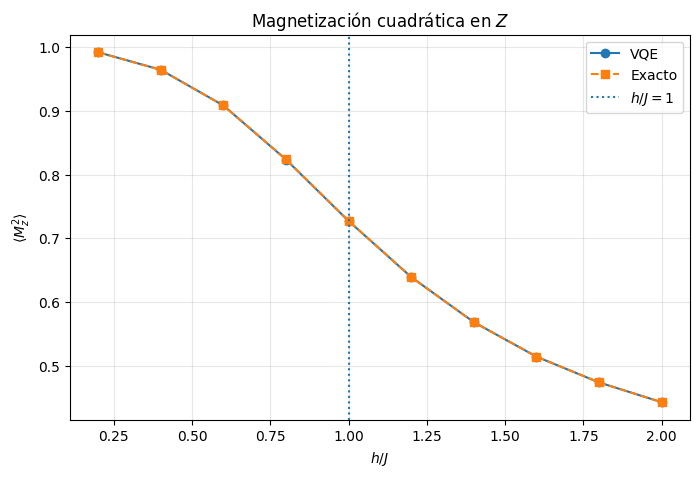

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabla["h/J"],
    tabla["Mz2_VQE"],
    marker="o",
    label="VQE",
)

plt.plot(
    tabla["h/J"],
    tabla["Mz2_exacto"],
    marker="s",
    linestyle="--",
    label="Exacto",
)

plt.axvline(
    1.0,
    linestyle=":",
    label=r"$h/J=1$",
)

plt.xlabel(r"$h/J$")
plt.ylabel(r"$\langle M_z^2\rangle$")
plt.title(r"Magnetización cuadrática en $Z$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

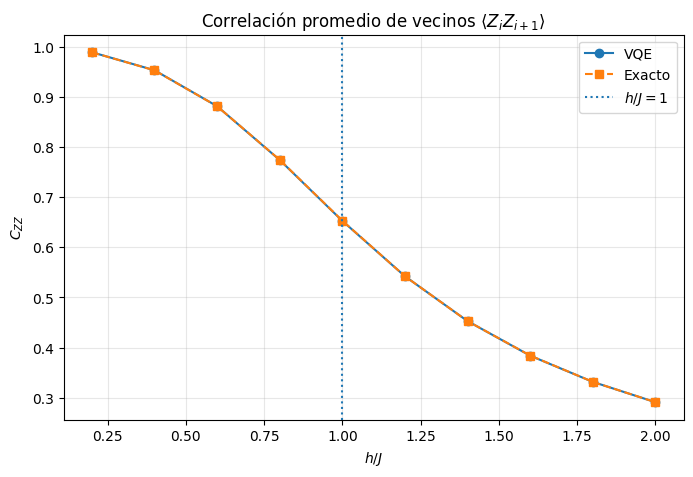

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabla["h/J"],
    tabla["Czz_VQE"],
    marker="o",
    label="VQE",
)

plt.plot(
    tabla["h/J"],
    tabla["Czz_exacto"],
    marker="s",
    linestyle="--",
    label="Exacto",
)

plt.axvline(
    1.0,
    linestyle=":",
    label=r"$h/J=1$",
)

plt.xlabel(r"$h/J$")
plt.ylabel(r"$C_{ZZ}$")
plt.title(r"Correlación promedio de vecinos $\langle Z_iZ_{i+1}\rangle$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

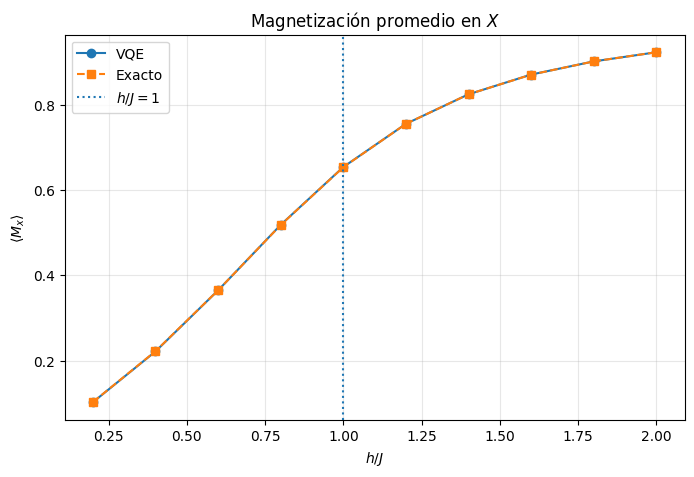

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabla["h/J"],
    tabla["Mx_VQE"],
    marker="o",
    label="VQE",
)

plt.plot(
    tabla["h/J"],
    tabla["Mx_exacto"],
    marker="s",
    linestyle="--",
    label="Exacto",
)

plt.axvline(
    1.0,
    linestyle=":",
    label=r"$h/J=1$",
)

plt.xlabel(r"$h/J$")
plt.ylabel(r"$\langle M_x\rangle$")
plt.title(r"Magnetización promedio en $X$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()